In [1]:
import torch
import numpy as np

import matplotlib.pyplot as plt

from olmo.tokenizer import Tokenizer

---

In [ ]:
# helper functions to find the position of the first padding token
def start_of_padding(labels, sample_idx, pad_token_id=1):
    sample_labels = labels[sample_idx, :]
    # find the position of the first padding token
    padding_positions = np.where(sample_labels == pad_token_id)[0]
    return padding_positions[0] if padding_positions.size > 0 else None


In [41]:
# convert a list of ids to a list of tokens
def ids_to_tokens(ids, tokenizer):
    tokens = []
    for idx in ids:
        tokens.append(tokenizer.base_tokenizer.id_to_token(idx))
    return tokens

---

In [2]:
# load the OLMo tokenizer
tokenizer = Tokenizer.from_file(
    "/home/mila/m/marius.mosbach/projects/olmo/olmo_data/tokenizers/allenai_dolma2.json",
    eos_token_id=100257,
    pad_token_id=100277,
)

In [7]:
# load the losses from the file
checkpoint_dir = "/network/scratch/m/marius.mosbach/olmo/checkpoints/slim_pajama/OLMo-136M-84M-a874c4ac5e47f478/step5000-unsharded"
file_name = "ppl-validation"
losses_N_T = torch.load(f"{checkpoint_dir}/{file_name}_losses.pt") # N samples, T tokens per sample
labels_N_T = torch.load(f"{checkpoint_dir}/{file_name}_labels.pt")

/tmp/ipykernel_3764100/3783035241.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  losses_N_T = torch.load(f"{checkpoint_dir}/{file_name}_losses.pt") # N samples, T token

In [8]:
losses_N_T.shape

torch.Size([8640, 1023])

In [44]:
# get labels for a single row (example)
example = 10
example_labels = labels_N_T[example, :]
print(example_labels)

tensor([  304, 19730, 18711,  ...,    68,  2011,  6056])


In [45]:
tokens = ids_to_tokens(example_labels, tokenizer)
print(tokens)

['Ġin', 'ĠHong', 'ĠKong', 'Ġto', 'Ġpromote', 'Ġprofessional', 'Ġexcellence', 'Ġin', 'Ġthe', 'Ġconstruction', 'Ġmanagement', 'Ġof', 'Ġboth', 'Ġbuilding', 'Ġand', 'Ġcivil', 'Ġworks', '.', 'ĠIt', 'Ġhas', 'Ġalways', 'Ġbeen', 'Ġthe', 'Ġprofessional', 'Ġand', 'Ġsocial', 'Ġresponsibility', 'Ġof', 'Ġthe', 'ĠInstitute', 'Ġto', 'Ġtake', 'Ġcare', 'Ġof', 'Ġthe', 'Ġdevelopment', 'Ġof', 'Ġthe', 'Ġconstruction', 'Ġmanagement', 'Ġprofession', ',', 'Ġat', 'Ġall', 'Ġlevels', '.Ċ', 'With', 'Ġa', 'Ġview', 'Ġto', 'Ġbroaden', 'Ġthe', 'Ġrepresentation', 'Ġof', 'Ġconstruction', 'Ġpractitioners', 'Ġand', 'Ġto', 'Ġwiden', 'Ġthe', 'Ġscope', 'Ġfor', 'Ġthe', 'Ġprofessional', 'Ġdevelopment', 'Ġneeds', 'Ġof', 'Ġfront', '-line', 'Ġsite', 'Ġsupervision', 'Ġpersonnel', ',', 'Ġthe', 'ĠInstitute', 'Ġhas', 'Ġstarted', 'Ġto', 'Ġadmit', 'ĠConstruction', 'ĠSupervisor', 'Ġmembers', 'Ġsince', 'Ġ', '200', '2', 'Ġand', 'Ġto', 'Ġmotivate', 'Ġsite', 'Ġsupervision', 'Ġpersonnel', 'Ġthrough', 'Ġsystematic', 'Ġsite', 'Ġmanagement', '

In [47]:
# find the position of the end of sequence token
eos_token = tokenizer.base_tokenizer.id_to_token(100257)
tokens.index(eos_token)

403

In [13]:
# decode the example into a string (this won't show the padding tokens)
decoded_example = tokenizer.decode(list(example_labels))
print(decoded_example)

 in Hong Kong to promote professional excellence in the construction management of both building and civil works. It has always been the professional and social responsibility of the Institute to take care of the development of the construction management profession, at all levels.
With a view to broaden the representation of construction practitioners and to widen the scope for the professional development needs of front-line site supervision personnel, the Institute has started to admit Construction Supervisor members since 2002 and to motivate site supervision personnel through systematic site management training and continuing professional development (CPD) activities provided by the Institute so as to enhance their professional status.
The role of site supervision personnel (which we classed as Construction Supervisor member) is important and in fact indispensable to ensure compliance of construction works with specifications, statutory, contractual and most of all, safety and env

In [18]:
# get the position of the first padding token
padding_position = start_of_padding(labels_N_T, sample_idx=example)
print(padding_position)
# get all losses for a single column

None


In [21]:
# print the losses until the padding token
print(len(example_labels[:padding_position]))
print(example_labels[:padding_position])

1023
tensor([  304, 19730, 18711,  ...,    68,  2011,  6056])


---

In [50]:
# get all losses for a single example
example = 10
example_losses = losses_N_T[example, :]
example_labels = labels_N_T[example, :]
print(example_losses.shape)
print(example_labels.shape)

torch.Size([1023])
torch.Size([1023])


In [53]:
# convert the labels to tokens
tokens = ids_to_tokens(example_labels, tokenizer)

# find the position of the end of sequence token
eos_token = tokenizer.base_tokenizer.id_to_token(100257)
document_boundary = tokens.index(eos_token)
print(f"Document boundary: {document_boundary}")

Document boundary: 403


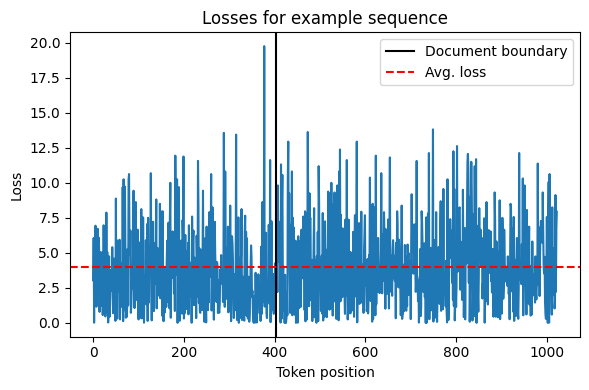

In [57]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4)) 

axes.plot(example_losses)
axes.axvline(document_boundary, color='black', linestyle='solid', label='Document boundary')
axes.axhline(torch.mean(example_losses, dim=0), color='red', linestyle='dashed', label='Avg. loss')


axes.set_xlabel('Token position')
axes.set_ylabel('Loss')
axes.set_title('Losses for example sequence')
axes.legend()

plt.tight_layout()
plt.show()

In [58]:
example_labels

tensor([  304, 19730, 18711,  ...,    68,  2011,  6056])

In [61]:
decoded_example = tokenizer.decode(list(example_labels[:document_boundary]))
print(decoded_example)

 in Hong Kong to promote professional excellence in the construction management of both building and civil works. It has always been the professional and social responsibility of the Institute to take care of the development of the construction management profession, at all levels.
With a view to broaden the representation of construction practitioners and to widen the scope for the professional development needs of front-line site supervision personnel, the Institute has started to admit Construction Supervisor members since 2002 and to motivate site supervision personnel through systematic site management training and continuing professional development (CPD) activities provided by the Institute so as to enhance their professional status.
The role of site supervision personnel (which we classed as Construction Supervisor member) is important and in fact indispensable to ensure compliance of construction works with specifications, statutory, contractual and most of all, safety and env

In [62]:
decoded_example = tokenizer.decode(list(example_labels[document_boundary:]))
print(decoded_example)

the most important unimportant subject
Tag Archives: Messi
Sam Jose
Posted on August 22, 2016 by mostimportantsubject
Jose Mourinho, photo by Aleksandr Osipov, http://www.flickr.com
It's the year of the manager. Jose, Pep, Antonio, Jurgen and Claudio – reads rather like a Euro boy band – are set to be the real superstars of the Premier League season. Meanwhile, Big Sam has taken on the big job of attempting to restore England's credibility at the international level.
The TV cameras will be trained on the dugouts more than ever as the aforementioned, plus Arsene, Slaven et al plot, scheme and tinker. The vast sums being paid by the broadcasters for their seat at the table means that the most important decisions the managers make will occur during the transfer windows. Take note Arsene.
Wenger must be getting a better interest rate than most in the UK who leave their money in the bank at the moment as he persists with his almost comical reluctance to invest. The joke is wearing thin for 